In [1]:
# Assingment 08
# Assingment No. 5

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [3]:
# Task-01

In [4]:
# Task-02

In [5]:
df = pd.read_csv("diabetes_data.csv")
df

,Age,BMI,Blood_Sugar
0,54,30.8,209
1,68,34.2,135
2,39,21.6,91
3,57,29.0,167
4,72,28.0,139
...,...,...,...
95,34,24.1,100
96,38,24.8,100
97,64,29.2,153
98,49,31.0,171


In [6]:
df.info

<bound method DataFrame.info of     Age   BMI  Blood_Sugar
0    54  30.8          209
1    68  34.2          135
2    39  21.6           91
3    57  29.0          167
4    72  28.0          139
..  ...   ...          ...
95   34  24.1          100
96   38  24.8          100
97   64  29.2          153
98   49  31.0          171
99   27  19.2           74

[100 rows x 3 columns]>

In [8]:
df.describe

<bound method NDFrame.describe of     Age   BMI  Blood_Sugar
0    54  30.8          209
1    68  34.2          135
2    39  21.6           91
3    57  29.0          167
4    72  28.0          139
..  ...   ...          ...
95   34  24.1          100
96   38  24.8          100
97   64  29.2          153
98   49  31.0          171
99   27  19.2           74

[100 rows x 3 columns]>

In [9]:
# Task-03

In [10]:
X = df[["Age", "BMI", "Blood_Sugar"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_scaled

array([[ 0.47972686,  0.42197577,  1.61843618],
       [ 1.36343423,  0.93676501,  0.05166123],
       [-0.46710247, -0.97098335, -0.87993469],
       [ 0.66909272,  0.14944029,  0.72918553],
       [ 1.61592205, -0.00196831,  0.13635177],
       [-0.46710247, -1.31922313, -1.11283367],
       [ 0.66909272,  1.19415963,  0.00931596],
       [-1.66641962, -0.50161669, -0.66820834],
       [-0.97207811, -0.63788443, -0.92227996],
       [-0.02524878,  0.33113061,  1.85133516],
       [ 1.23719032,  1.28500479,  1.57609091],
       [-1.35080984, -0.42591239, -0.54117254],
       [ 0.10099513,  0.21000373,  1.68195408],
       [ 0.85845859,  1.70894887,  0.19986967],
       [-0.53022442, -0.98612421, -1.1340063 ],
       [ 0.79533664,  1.54239941,  1.00442978],
       [ 0.66909272,  0.81563813,  0.53863182],
       [-0.59334638, -0.91041991, -1.17635157],
       [ 0.03787317,  1.05789189,  0.81387607],
       [ 1.30031228,  1.46669511,  0.64449499],
       [-0.08837074, -0.06253175,  1.110

In [12]:
# Task-04

In [13]:
kmeans = KMeans(n_clusters=2, init="k-means++", random_state=42, n_init=10)
kmeans.fit(X_scaled)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [14]:
# Task-05

In [15]:
df["Cluster"] = kmeans.predict(X_scaled)
print(df["Cluster"].value_counts().sort_index())

Cluster
0    50
1    50
Name: count, dtype: int64


In [16]:
# Task--06

In [18]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Age", "BMI", "Blood_Sugar"]
)
centers.index.name = "Cluster"

In [20]:
centers

,Age,BMI,Blood_Sugar
Cluster,,,
0,0.867296,0.890131,0.904918
1,-0.867296,-0.890131,-0.904918


In [21]:
# Task-07

Text(0.5, 1.0, 'Diabetes Patient Clusters (BMI vs Blood Sugar)')

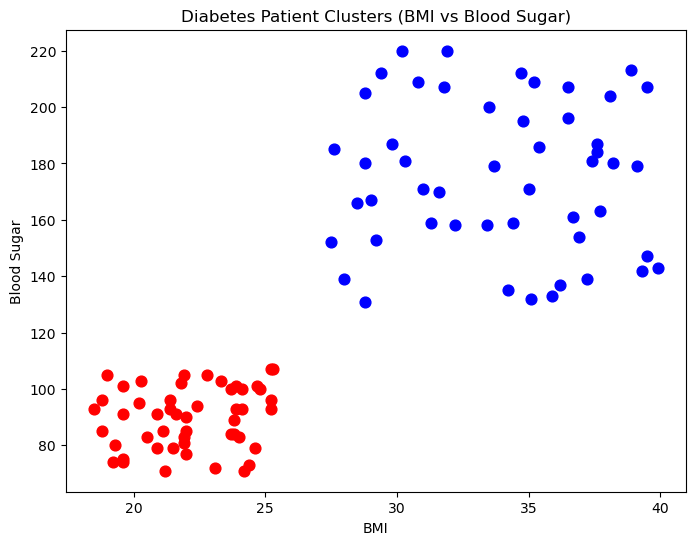

In [23]:
colors = ["blue", "red"]
plt.figure(figsize=(8, 6))
for cluster_num in range(2):
    cluster_data = df[df["Cluster"] == cluster_num]
    plt.scatter(
        cluster_data["BMI"],
        cluster_data["Blood_Sugar"],
        s=60,
        color=colors[cluster_num],
        label=f"Cluster {cluster_num}"
    )

plt.xlabel("BMI")
plt.ylabel("Blood Sugar")
plt.title("Diabetes Patient Clusters (BMI vs Blood Sugar)")